# Feature Selection

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFECV, VarianceThreshold, SelectKBest, mutual_info_classif, SelectKBest, SequentialFeatureSelector
from sklearn.linear_model import Lasso
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

In [5]:
import os
os.chdir(r'C:\Users\user\Desktop\PI_Code\Pre_Processing_2')
get_ipython().run_line_magic('run', 'pre_processing2.ipynb')

Columns with string values: Index([], dtype='object')
Columns with all zeros (representing 'unknown'):
Index(['original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis',
       'original_firstorder_MeanAbsoluteDeviation',
       'original_firstorder_Range',
       'original_firstorder_RobustMeanAbsoluteDeviation',
       'original_firstorder_Skewness', 'original_firstorder_Variance',
       'original_glcm_ClusterProminence', 'original_glcm_ClusterShade',
       'original_glcm_ClusterTendency', 'original_glcm_Contrast',
       'original_glcm_DifferenceAverage', 'original_glcm_DifferenceVariance',
       'original_glcm_Imc1', 'original_glcm_Imc2',
       'original_glcm_InverseVariance', 'original_glcm_SumSquares',
       'original_glrlm_GrayLevelVariance', 'original_glszm_GrayLevelVariance',
       'original_gldm_GrayLevelVariance'],
      dtype='object')


# Recursive Feature Elimination (RFE)

In [7]:
# RFE model 

def rfe(dataframe, target_column, num_features_to_select=5):

    X = dataframe.drop(columns=[target_column])
    y = dataframe[target_column]
    
     # Create an RFE model with cross-validation and random forest classifier
    model = RandomForestClassifier()
    rfe = RFECV(model, step=1, cv=5, scoring='accuracy', min_features_to_select=num_features_to_select)
    
   
    rfe.fit(X, y)
    
    # Get the selected features
    selected_features = X.columns[rfe.support_]
    
    return selected_features

In [15]:
selected_features = rfe(prep_data, 'Malignancy')
print("Selected Features:", selected_features)

Selected Features: Index(['Nodule_id', 'Patient_id', 'Subtlety', 'Internalstructure',
       'Calcification', 'Sphericity', 'Margin', 'Lobulation', 'Spiculation',
       'Texture', 'original_shape_Elongation', 'original_shape_Flatness',
       'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength',
       'original_shape_Maximum2DDiameterColumn',
       'original_shape_Maximum2DDiameterRow',
       'original_shape_Maximum2DDiameterSlice',
       'original_shape_MinorAxisLength', 'original_shape_Sphericity',
       'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio',
       'original_shape_VoxelVolume', 'original_firstorder_10Percentile',
       'original_firstorder_Energy', 'original_firstorder_TotalEnergy',
       'original_glcm_JointAverage', 'original_glcm_Correlation',
       'original_glcm_DifferenceEntropy', 'original_glcm_JointEnergy',
       'original_glcm_JointEntropy', 'original_glcm_Idm', 'original_glcm_Idmn',
       'original_glrlm_GrayLevelNonUnif

# Feature Importance from Trees

In [17]:
# Create a feature selection model with random forest

def feature_select_trees(threshold, dataframe, target_column):

    X = dataframe.drop(columns=[target_column])
    y = dataframe[target_column]

    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)
    
    # Get the feature importances
    feature_importances = model.feature_importances_
    selected_features = X.columns[feature_importances > threshold]

    return selected_features 

In [19]:
#threshold 0.01
prep_data_01 = feature_select_trees(0.01,prep_data, 'Malignancy')

#threshold 0.02
prep_data_02 = feature_select_trees(0.02, prep_data, 'Malignancy')

print("Threshold 0.01:")
print("prep_data:")
print(prep_data_01)

print()

print("Threshold 0.02:")
print("prep_data:")
print(prep_data_02)

print()


Threshold 0.01:
prep_data:
Index(['Nodule_id', 'Patient_id', 'Calcification',
       'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength',
       'original_shape_Maximum2DDiameterColumn',
       'original_shape_Maximum2DDiameterRow',
       'original_shape_Maximum2DDiameterSlice',
       'original_shape_MinorAxisLength', 'original_shape_SurfaceArea',
       'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume',
       'original_firstorder_Energy', 'original_firstorder_TotalEnergy',
       'original_glrlm_GrayLevelNonUniformity',
       'original_glrlm_LongRunEmphasis',
       'original_glrlm_LongRunHighGrayLevelEmphasis',
       'original_glrlm_LongRunLowGrayLevelEmphasis',
       'original_glrlm_RunEntropy', 'original_glrlm_RunLengthNonUniformity',
       'original_glrlm_RunVariance', 'original_glszm_GrayLevelNonUniformity',
       'original_glszm_SizeZoneNonUniformityNormalized',
       'original_glszm_ZoneEntropy', 'original_glszm_ZoneVariance',
       'ori

# Lasso

In [21]:
#Create a Lasso model with a regularization coefficient of 0.01

def lasso(dataframe, target_column):

    X = dataframe.drop(columns=[target_column])
    y = dataframe[target_column]

    model = Lasso(alpha=0.01)
    model.fit(X, y)
    selected_features = X.columns[model.coef_ != 0]

    return selected_features

In [23]:
print("Lasso:")
prep_data_lasso = lasso(prep_data, 'Malignancy')
print(prep_data_lasso)

Lasso:
Index(['Nodule_id', 'Patient_id', 'Subtlety', 'Calcification', 'Margin',
       'Lobulation', 'Spiculation', 'original_shape_LeastAxisLength',
       'original_shape_MajorAxisLength',
       'original_shape_Maximum2DDiameterColumn',
       'original_shape_Maximum2DDiameterRow', 'original_shape_MinorAxisLength',
       'original_shape_SurfaceArea', 'original_shape_VoxelVolume',
       'original_firstorder_Energy', 'original_firstorder_TotalEnergy',
       'original_glrlm_GrayLevelNonUniformity',
       'original_glrlm_LongRunEmphasis',
       'original_glrlm_LongRunHighGrayLevelEmphasis',
       'original_glrlm_LongRunLowGrayLevelEmphasis',
       'original_glrlm_RunLengthNonUniformity',
       'original_glszm_GrayLevelNonUniformity',
       'original_glszm_LargeAreaEmphasis',
       'original_glszm_LargeAreaHighGrayLevelEmphasis',
       'original_glszm_LargeAreaLowGrayLevelEmphasis',
       'original_glszm_ZoneVariance', 'original_gldm_DependenceNonUniformity',
       'original

C:\Users\user\anaconda3\envs\new_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.659e+01, tolerance: 3.469e-02
  model = cd_fast.enet_coordinate_descent(


# Choosing the best features

### Metrics

### 1. CrossValidation

#### rfe

In [27]:
Y = prep_data['Malignancy']
X = prep_data[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Applying StratifiedKFold for cross validation and RandomForestClassifier
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(random_state=42)

cv_scores_rfe = cross_val_score(model, X_train, y_train, cv=stratified_kfold, scoring='accuracy')
model.fit(X_train, y_train)

y_pred_group = model.predict(X_test)
accuracy_rfe = accuracy_score(y_test, y_pred_group)

cv_scores_rfe.mean(), accuracy_rfe


(0.8946153846153848, 0.8830769230769231)

#### tree

In [29]:
#threshold 0.01
Y = prep_data['Malignancy']
X = prep_data[prep_data_01]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Applying StratifiedKFold for cross validation and RandomForestClassifier
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(random_state=42)

cv_scores_tree_01 = cross_val_score(model, X_train, y_train, cv=stratified_kfold, scoring='accuracy')
model.fit(X_train, y_train)

y_pred_group = model.predict(X_test)
accuracy_tree_01 = accuracy_score(y_test, y_pred_group)

cv_scores_tree_01.mean(), accuracy_tree_01

(0.8923076923076924, 0.88)

In [31]:
#threshold 0.02
Y = prep_data['Malignancy']
X = prep_data[prep_data_02]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Applying StratifiedKFold for cross validation and RandomForestClassifier
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(random_state=42)

cv_scores_tree_02 = cross_val_score(model, X_train, y_train, cv=stratified_kfold, scoring='accuracy')
model.fit(X_train, y_train)

y_pred_group = model.predict(X_test)
accuracy_tree_02 = accuracy_score(y_test, y_pred_group)

cv_scores_tree_02.mean(), accuracy_tree_02

(0.8923076923076924, 0.8953846153846153)

#### Lasso

In [35]:
#sd = 0.5
Y = prep_data['Malignancy']
X = prep_data[prep_data_lasso]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Applying StratifiedKFold for cross validation and RandomForestClassifier
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(random_state=42)

cv_scores_lasso = cross_val_score(model, X_train, y_train, cv=stratified_kfold, scoring='accuracy')
model.fit(X_train, y_train)

y_pred_group = model.predict(X_test)
accuracy_lasso = accuracy_score(y_test, y_pred_group)

cv_scores_lasso.mean(), accuracy_lasso

(0.9, 0.8830769230769231)

## Cross-Validation Score Comparison

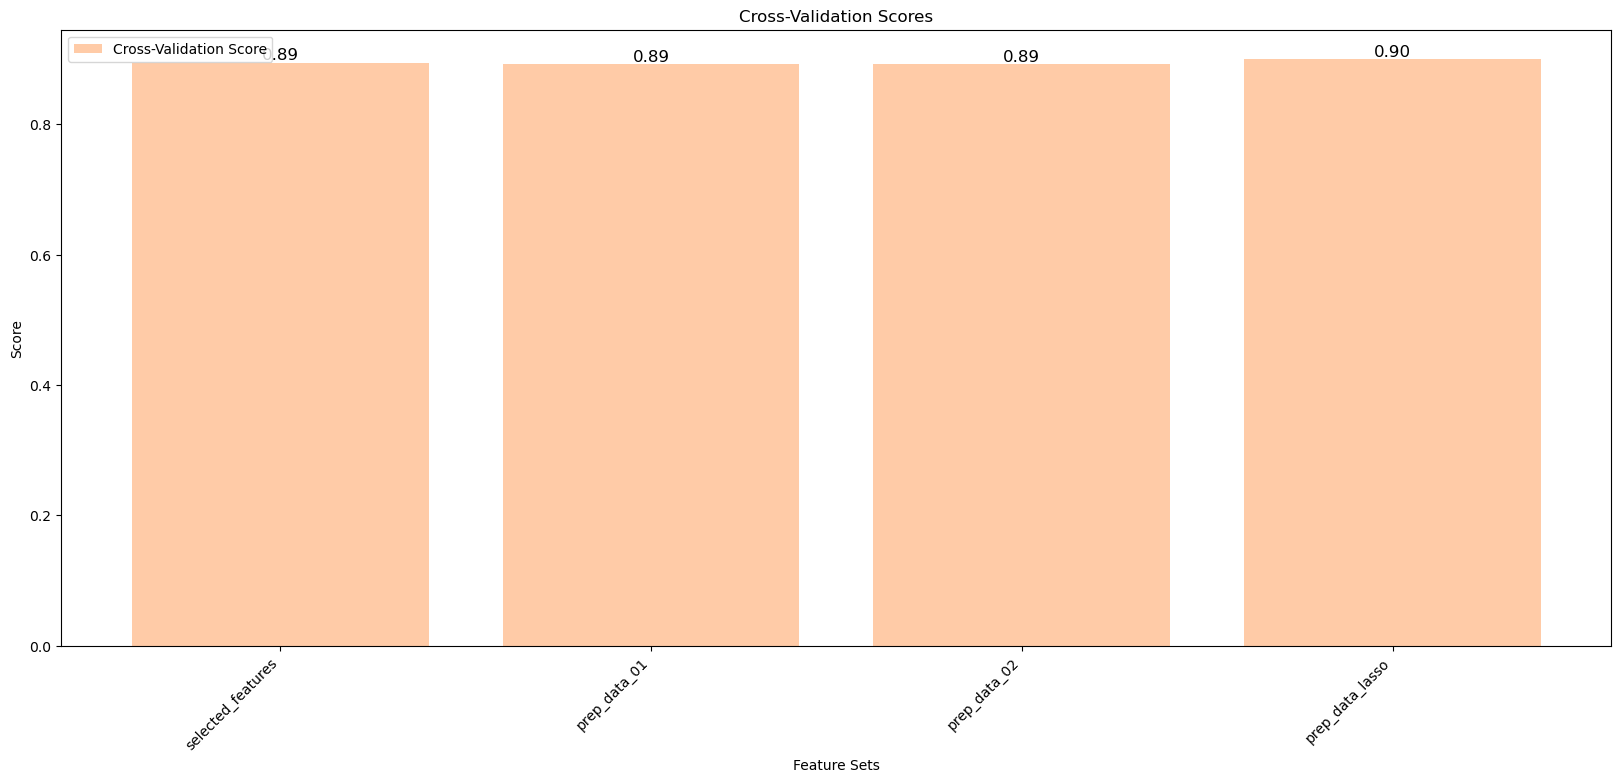

In [37]:

feature_sets = ["selected_features", "prep_data_01", "prep_data_02", "prep_data_lasso"]
# List of cross-validation scores corresponding to each feature set
cross_val_scores = [cv_scores_rfe,cv_scores_tree_01,cv_scores_tree_02, cv_scores_lasso, ]

# Create a bar chart for cross-validation scores
plt.figure(figsize=(20, 8))
bars = plt.bar(feature_sets, [score.mean() for score in cross_val_scores], color='#FF7F24', alpha=0.4, label='Cross-Validation Score')
plt.xlabel('Feature Sets')
plt.ylabel('Score')
plt.xticks(rotation=45, ha="right")  
plt.legend(loc='best')
plt.title('Cross-Validation Scores')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=12, color='black')

